# Mercury's Primary Atmosphere for Namur et al. (2026)

**Author:** Kaustubh Hakim

**Date:** 11 May 2026

**Email:** kaustubh.hakim@kuleuven.be

### Make sure Atmodeller v2 is installed in your Python environment.



This notebook uses Atmodeller, an interior-atmosphere code originally developed by Dr. Dan J. Bower (ETH Zürich).

Bower, D. J., Thompson, M. A., Hakim, K., Tian, M., and Sossi, P. A. (2025), Diversity of low-mass planet atmospheres in the C–H–O–N–S–Cl system with interior dissolution, nonideality and condensation: Application to TRAPPIST-1e and sub-Neptunes, The Astrophysical Journal, 995(1), 59, doi: https://www.doi.org/10.3847/1538-4357/ae1479. ArXiv e-print [2507.00499](https://arxiv.org/abs/2507.00499)

#### Follow the following steps to install the appropriate version of Atmodeller to run this notebook.

Step 1. Create an Atmodeller environment with a recommended Python version

```console
conda create -n atmodeller python=3.11 -y
conda activate atmodeller
```

Step 2. Install package from branch

```console
pip install git+https://github.com/kaustubhhakim/atmodeller.git@kaustubhhakim/v2preview
```

Step 3. Install Jupyter + kernel

```console
pip install jupyter ipykernel
python -m ipykernel install --user --name atmodeller-v2preview --display-name "Python (atmodeller v2preview)"
```


Step 4. Get the notebook (skip this step if you already possess this notebook)


```console
git clone https://github.com/kaustubhhakim/atmodeller.git
cd atmodeller
git checkout kaustubhhakim/v2preview
```

Step 5. Run the notebook by selecting the Jupyter kernel "Python (atmodeller v2preview)"

```console
jupyter notebook
```

## Import libraries

In [1]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from jaxtyping import ArrayLike
from molmass import Formula
from scipy.constants import mega
from scipy.optimize import curve_fit

from atmodeller import (
    ChemicalSpecies,
    EquilibriumModel,
    FixedActivityConstraint,
    PurePhase,
    ReservoirSpecies,
    ThermodynamicState,
    IronWustiteBuffer,
    Planet,
    debug_logger,
    unit_conversion,
)
from atmodeller.sci_utils import SIO2_MOLAR_MASS
from atmodeller.solubility import get_solubility_models

logger: logging.Logger = debug_logger()
logger.setLevel(logging.INFO)

from typing import Tuple, List, Dict, Any

# For more output use DEBUG
# logger.setLevel(logging.DEBUG)

## Model setup

In [2]:
# Gas species
CO_g = ChemicalSpecies.create_gas("CO")
O2_g = ChemicalSpecies.create_gas("O2")
CO2_g = ChemicalSpecies.create_gas("CO2")
H2_g = ChemicalSpecies.create_gas("H2")
H2O_g = ChemicalSpecies.create_gas("H2O")
CH4_g = ChemicalSpecies.create_gas("CH4")
S2_g = ChemicalSpecies.create_gas("S2")
SO2_g = ChemicalSpecies.create_gas("SO2")
H2S_g = ChemicalSpecies.create_gas("H2S")
N2_g = ChemicalSpecies.create_gas("N2")

gas_species_CO = (CO_g, O2_g, CO2_g)
gas_species_COH = (CO_g, O2_g, CO2_g, H2_g, H2O_g, CH4_g)
gas_species_COHNS = (CO_g, O2_g, CO2_g, H2_g, H2O_g, CH4_g, N2_g, S2_g, SO2_g, H2S_g)

# Melt species
solubility_models = get_solubility_models()

# Include mass of species in melt from mass balance constraints for self consistency
include_in_phase_mass = True

CO_d = ReservoirSpecies.create_dissolved(
    "CO",
    solubility=solubility_models["CO_basalt_armstrong15"],
    include_in_phase_mass=include_in_phase_mass,
)
CO2_d = ReservoirSpecies.create_dissolved(
    "CO2",
    solubility=solubility_models["CO2_basalt_dixon95"],
    include_in_phase_mass=include_in_phase_mass,
)
H2_d = ReservoirSpecies.create_dissolved(
    "H2",
    solubility=solubility_models["H2_basalt_hirschmann12"],
    include_in_phase_mass=include_in_phase_mass,
)
H2O_d = ReservoirSpecies.create_dissolved(
    "H2O",
    solubility=solubility_models["H2O_basalt_dixon95"],
    include_in_phase_mass=include_in_phase_mass,
)
CH4_d = ReservoirSpecies.create_dissolved(
    "CH4",
    solubility=solubility_models["CH4_basalt_ardia13"],
    include_in_phase_mass=include_in_phase_mass,
)
N2_d = ReservoirSpecies.create_dissolved(
    "N2",
    solubility=solubility_models["N2_basalt_libourel03"],
    include_in_phase_mass=include_in_phase_mass,
)
S2_d = ReservoirSpecies.create_dissolved(
    "S2",
    solubility=solubility_models["S2_basalt_boulliung23"],
    include_in_phase_mass=include_in_phase_mass,
)

melt_species_CO = (CO_d, CO2_d)
melt_species_COH = (CO_d, CO2_d, H2_d, H2O_d)
melt_species_COHNS = (CO_d, CO2_d, H2_d, H2O_d, N2_d, S2_d)

# Condensates
graphite = PurePhase.from_species("C", state="s", solve_for_stability=True)
condensate_phases = (graphite,)

[16:24:12 - atmodeller.phases              - INFO     ] - Creating PurePhase: ('C_s: ActivityCoefficient',)


## Planet Parameters

In [3]:
temperature_celsius_earth = 1500
temperature_K_earth = temperature_celsius_earth + 273.15

earth_mass = 5.98e24 # kg
earth_radius = 6400e3 # m

# Bulk silicate Earth mass
mass_BSE = 4.0e24 # kg

temperature_celsius_mercury = 1400
temperature_K_mercury = temperature_celsius_mercury + 273.15

mercury_mass = 3.285e23 # kg
mercury_radius = 2440e3 # m

# Bulk silicate Mercury mass
mass_BSM = 1e23 # kg

# MErcury core mass fraction (CMF)
mercury_CMF = 0.7

## Fugacity Constraints

In [4]:
input_delIW = np.linspace(-8, -3)
fugacity_constraints = {"O2_g": IronWustiteBuffer(input_delIW)}

## Mass Constraints - Namur et al. (2026)

In [5]:
# EH composition - Lodders (2021) Table 1 (Space Science Reviews 217:44)
# DOI: https://doi.org/10.1007/s11214-021-00825-8
C_EH = 3600.0 / mega 
H_EH = 630.0 / mega 
N_EH = 600.0 / mega
S_EH = 56000.0 / mega

print("H2O ppm = ", round(H_EH * mega *  Formula("H2O").mass /  Formula("H2").mass), 
      "for H ppm = ", H_EH * mega)

# Mass of volatiles scaled up from per unit mass of basalt to mass of bulk silicate Mercury (BSM)
C_mass = C_EH * mass_BSM
H_mass = H_EH * mass_BSM
N_mass = N_EH * mass_BSM
S_mass = S_EH * mass_BSM

# # Earth-like volatile composition (MAGWORLD I https://calcul-isto.cnrs-orleans.fr/apps/planet/)
# C_EH = 4000.0 / mega 
# H2O_EH = 4000.0 / mega 

# # Mass of volatiles scaled up from per unit mass of basalt to mass of bulk silicate Mercury (BSM)
# C_mass = C_EH * mass_BSM
# H_mass = H2O_EH * Formula("H2").mass / Formula("H2O").mass * mass_BSM

mass_constraints_CO: dict[str, ArrayLike] = {"C": C_mass}
mass_constraints_COH: dict[str, ArrayLike] = {"C": C_mass, "H": H_mass}
mass_constraints_COHNS: dict[str, ArrayLike] = {"C": C_mass, "H": H_mass, "N": N_mass, "S": S_mass}

H2O ppm =  5630 for H ppm =  630.0


## Model COHNS - Namur et al. (2026)

In [6]:
planet = Planet.from_species(
    gas_species_COHNS,
    temperature=temperature_K_mercury,
    silicate_melt_species=melt_species_COHNS,
    core_mass_fraction=mercury_CMF,
    planet_mass=mercury_mass,
    surface_radius=mercury_radius,
    mantle_melt_fraction=1,
    condensates=condensate_phases,
)

model = EquilibriumModel.from_state(
    planet, activity_constraints=fugacity_constraints, mass_constraints=mass_constraints_COHNS
)

# Solve with an automatic initial guess and default solver settings
output = model.solve_with_default()

# Optionally print solver stats to the logger
output.solver_stats_to_logger()

# output.quick_look()

# Optionally dump the output to Excel (uncomment the line below)
output.to_excel("mercury_outgassing_Namur2026_COHNS")

data = output.to_dataframes("elements_species")

[16:24:12 - atmodeller.phases              - INFO     ] - Creating GasPhase: ('CO_g: IdealGas', 'O2_g: IdealGas', 'CO2_g: IdealGas', 'H2_g: IdealGas', 'H2O_g: IdealGas', 'CH4_g: IdealGas', 'N2_g: IdealGas', 'S2_g: IdealGas', 'O2S_g: IdealGas', 'H2S_g: IdealGas')
[16:24:12 - atmodeller.phases              - INFO     ] - Creating CondensedPhase: ('CO_d: _CO_basalt_armstrong15', 'CO2_d: _CO2_basalt_dixon95', 'H2_d: SolubilityPowerLawLog10', 'H2O_d: SolubilityPowerLaw', 'N2_d: _N2_basalt_libourel03', 'S2_d: _S2_basalt_boulliung23')
[16:24:12 - atmodeller.phases              - INFO     ] - Creating CondensedPhase: ()
[16:24:12 - atmodeller.phases              - INFO     ] - Creating CondensedPhase: ()
[16:24:12 - atmodeller.reactions           - INFO     ] - ReactionNetwork network = {0: '1.0 CO_g + 2.0 H2_g = 0.5 O2_g + 1.0 CH4_g',
 1: '1.0 CO_g + 0.5 O2_g = 1.0 CO2_g',
 2: '0.5 O2_g + 1.0 H2_g = 1.0 H2O_g',
 3: '1.0 O2_g + 0.5 S2_g = 1.0 O2S_g',
 4: '1.0 H2_g + 0.5 S2_g = 1.0 H2S_g',
 5: 

## Import MAGWORLD-I output

Running this code block requires MAGWORLD-I.xlsx to be present in the same directory as this notebook

In [7]:
df = pd.read_excel("MAGWORLD-I.xlsx", header=[0, 1, 2])

delIW_MAGWORLD = df[("Target", "DIW")].values.flatten()

atm_wt_MAGWORLD = { 
    "H2O": df[("Atmosphere", "H2O", "%wt")],
    "H2": df[("Atmosphere", "H2", "%wt")],
    "CO2": df[("Atmosphere", "CO2", "%wt")],
    "CO": df[("Atmosphere", "CO", "%wt")],
    "CH4": df[("Atmosphere", "CH4", "%wt")],
    "O2": df[("Atmosphere", "O2", "%wt")],
    "H2S": df[("Atmosphere", "H2S", "%wt")],
    "SO2": df[("Atmosphere", "SO2", "%wt")],
    "S2": df[("Atmosphere", "S2", "%wt")],
    "N2": df[("Atmosphere", "N2", "%wt")]
} 

mass_atm_g = df[("Atmosphere", "Mass", "g")]
total_pressure_MAGWORLD = df[("Atmosphere", "P tot", "bar")]

atm_moles_MAGWORLD = {
    "H2O": atm_wt_MAGWORLD["H2O"] / 100 * mass_atm_g / Formula("H2O").mass,
    "H2": atm_wt_MAGWORLD["H2"] / 100 * mass_atm_g / Formula("H2").mass,
    "CO2": atm_wt_MAGWORLD["CO2"] / 100 * mass_atm_g / Formula("CO2").mass,
    "CO": atm_wt_MAGWORLD["CO"] / 100 * mass_atm_g / Formula("CO").mass,
    "CH4": atm_wt_MAGWORLD["CH4"] / 100 * mass_atm_g / Formula("CH4").mass,
    "O2": atm_wt_MAGWORLD["O2"] / 100 * mass_atm_g / Formula("O2").mass,
    "H2S": atm_wt_MAGWORLD["H2S"] / 100 * mass_atm_g / Formula("H2S").mass,
    "SO2": atm_wt_MAGWORLD["SO2"] / 100 * mass_atm_g / Formula("SO2").mass,
    "S2": atm_wt_MAGWORLD["S2"] / 100 * mass_atm_g / Formula("S2").mass,
    "N2": atm_wt_MAGWORLD["N2"] / 100 * mass_atm_g / Formula("N2").mass
}

total_moles = sum(atm_moles_MAGWORLD.values())

# pressures in bar
pressures_MAGWORLD = {
    "H2O_g": atm_moles_MAGWORLD["H2O"] / total_moles * total_pressure_MAGWORLD,
    "H2_g": atm_moles_MAGWORLD["H2"] / total_moles * total_pressure_MAGWORLD,
    "CO2_g": atm_moles_MAGWORLD["CO2"] / total_moles * total_pressure_MAGWORLD,
    "CO_g": atm_moles_MAGWORLD["CO"] / total_moles * total_pressure_MAGWORLD, 
    "CH4_g": atm_moles_MAGWORLD["CH4"] / total_moles * total_pressure_MAGWORLD,
    "O2_g": atm_moles_MAGWORLD["O2"] / total_moles * total_pressure_MAGWORLD,
    "H2S_g": atm_moles_MAGWORLD["H2S"] / total_moles * total_pressure_MAGWORLD,
    "O2S_g": atm_moles_MAGWORLD["SO2"] / total_moles * total_pressure_MAGWORLD,
    "S2_g": atm_moles_MAGWORLD["S2"] / total_moles * total_pressure_MAGWORLD,
    "N2_g": atm_moles_MAGWORLD["N2"] / total_moles * total_pressure_MAGWORLD
}

C_g_MAGWORLD = (
    atm_wt_MAGWORLD["CO"] / Formula("CO").mass + 
    atm_wt_MAGWORLD["CO2"] / Formula("CO2").mass + 
    atm_wt_MAGWORLD["CH4"] / Formula("CH4").mass
    ) / 100 * mass_atm_g * Formula("C").mass 

melt_ppm_MAGWORLD = {
    "H2O_d": df[("Silicate melt", "H2O", "ppm")],
    "H2_d": df[("Silicate melt", "H2", "ppm")],
    "CO2_d": df[("Silicate melt", "CO2", "ppm")],
    "CO_d": df[("Silicate melt", "CO", "ppm")],
    "S_d": df[("Silicate melt", "S", "ppm")],
    "N2_d": df[("Silicate melt", "N", "ppm")]
}

graphite_ppm_MAGWORLD = df[("Graphite", "C", "ppm")]

/var/folders/tr/n7zmn6sd1j51684lqd48fhr4dpl1kt/T/ipykernel_92825/2378204299.py:3: PerformanceWarning: indexing past lexsort depth may impact performance.
  delIW_MAGWORLD = df[("Target", "DIW")].values.flatten()


## Plot COHNS - Supplementary Fig. 13 Namur et al. (2026)

<>:17: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:17: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/var/folders/tr/n7zmn6sd1j51684lqd48fhr4dpl1kt/T/ipykernel_92825/926213080.py:17: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  ax.set_title(f"Primary atmosphere of Mercury (EH, {temperature_celsius_mercury}$^\circ$C)",


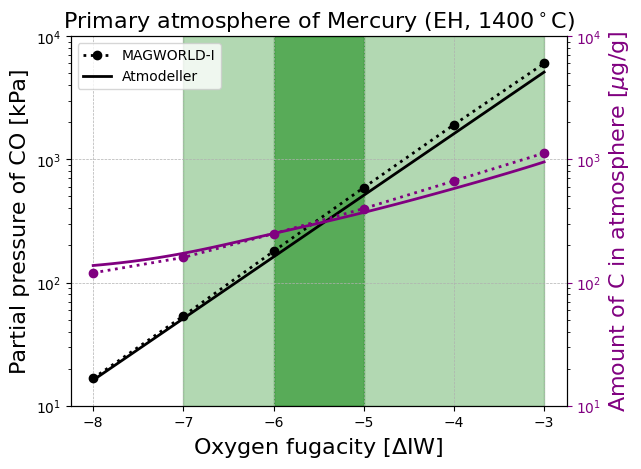

In [8]:
# Get data as dataframes
data = output.to_dataframes("elements_species")

fig, ax = plt.subplots()

ax.axvspan(-7, -3, color='green', alpha=0.3)
ax.axvspan(-6, -5, color='green', alpha=0.5)

ax.plot(delIW_MAGWORLD, pressures_MAGWORLD["CO_g"].values * 1e2 , marker="o", ls=":", lw=2,
        label="MAGWORLD-I", color="black")

# unit conversion from bar to kPa = 1e2
ax.plot(input_delIW, 1e2 * data["CO_g"]["gas.partial_pressure"], lw=2,
        label="Atmodeller", color="black")

ax.set_yscale('log')
ax.set_title(f"Primary atmosphere of Mercury (EH, {temperature_celsius_mercury}$^\circ$C)", 
             fontsize=16)
ax.set_xlabel(r"Oxygen fugacity [$\Delta$IW]", fontsize=16)
ax.set_ylabel("Partial pressure of CO [kPa]", fontsize=16)

#ax.set_xlim(-8, -3)
ax.set_ylim(1e1, 1e4)

ax.legend(loc="upper left")

ax.grid(True, which="major", axis="both", ls="--", lw=0.5)

ax1 = ax.twinx()

# unit conversion from g/g to micro-g/g = mega = 1e6
ax1.plot(delIW_MAGWORLD, C_g_MAGWORLD.values / mass_BSM * mega, marker="o", 
         label=r"MAGWORLD-I", color="purple", lw=2, ls=':')
ax1.plot(input_delIW, mega * data["C"]["gas.mass"]/mass_BSM, 
         label=r"Atmodeller", color="purple", lw=2, ls='-')

ax1.set_ylabel(r"Amount of C in atmosphere [$\mu$g/g]", color="purple", fontsize=16)
ax1.set_yscale("log")
ax1.set_ylim(1e1, 1e4)
ax1.tick_params(axis='y', colors='purple')

# labelLines(ax.get_lines(), xvals = [-5, -4])
# labelLines(ax1.get_lines(), xvals = [-6.5, -7.5])

plt.savefig("mercury_outgassing_Namur2026_COHNS.pdf", bbox_inches='tight')
plt.savefig("mercury_outgassing_Namur2026_COHNS.png", bbox_inches='tight')

## Fit C(atm) vs delta IW - Namur et al. (2026)

In [9]:
def quadratic_fit(x: ArrayLike, a: float, b: float, c: float) -> ArrayLike:
    return a + b * x + c * x**2 

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res/ss_tot

# Atmodeller

x = input_delIW
y = mega * data["C"]["gas.mass"]/mass_BSM 

params_quad, cov_quad = curve_fit(quadratic_fit, x, y)
a_q, b_q, c_q = params_quad

print("Quadratic fit Atmodeller: a =", round(a_q), ", b =", round(b_q, 1), ", c =", round(c_q, 2))


y_quad = quadratic_fit(x, *params_quad)
print(r"Quadratic R$^2$ Atmodeller:", round(r2(y, y_quad), 4))

# MAGWORLD-I

x = delIW_MAGWORLD
y = C_g_MAGWORLD.values / mass_BSM * mega

params_quad, cov_quad = curve_fit(quadratic_fit, x, y)
a_q, b_q, c_q = params_quad

print("Quadratic fit MAGWORLD-I: a =", round(a_q), ", b =", round(b_q, 1), ", c =", round(c_q, 2))

y_quad = quadratic_fit(x, *params_quad)
print(r"Quadratic R$^2$ MAGWORLD-I:", round(r2(y, y_quad), 4))

Quadratic fit Atmodeller: a = 2240 , b = 560.1 , c = 37.62
Quadratic R$^2$ Atmodeller: 0.994
Quadratic fit MAGWORLD-I: a = 2869 , b = 740.5 , c = 49.94
Quadratic R$^2$ MAGWORLD-I: 0.9942


## Additional Figure - Atmosphere and Melt Speciation

<>:78: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:92: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:78: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:92: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/var/folders/tr/n7zmn6sd1j51684lqd48fhr4dpl1kt/T/ipykernel_92825/3179326340.py:78: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  ax.set_title(f"Atmospheric speciation (EH, {temperature_celsius_mercury}$^\circ$C)", fontsize=12)
/var/folders/tr/n7zmn6sd1j51684lqd48fhr4dpl1kt/T/ipyke

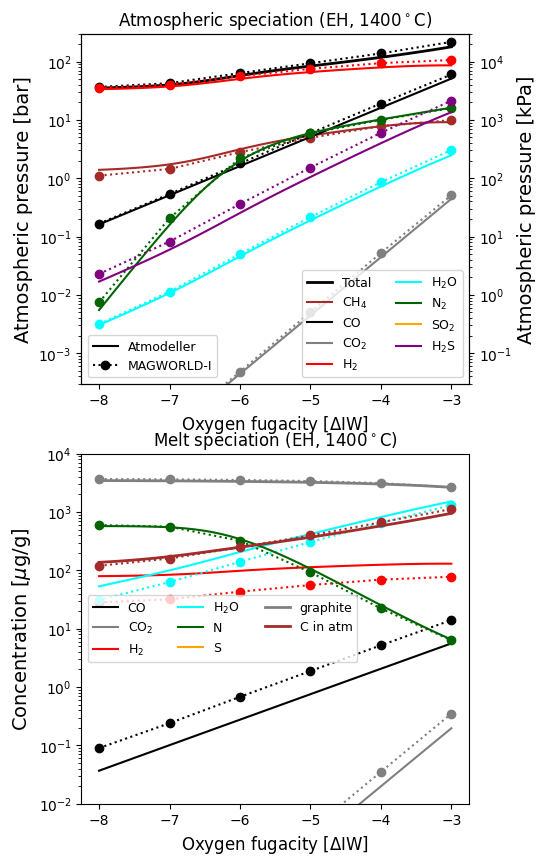

In [10]:
# Get data as dataframes
data = output.to_dataframes("elements_species")

# Plot total pressure on the x-axis
total_pressure = data["state"]["pressure"]

# Pick colours 
colors = {
    "CH4_g": "brown",
    "CO_g": "black",
    "CO2_g": "gray",
    "H2_g": "red",
    "H2O_g": "cyan",
    "N2_g": "darkgreen",
    "O2S_g": "orange",
    "H2S_g": "purple",
}

labels = {
    "CH4_g": "CH$_4$",
    "CO_g": "CO",
    "CO2_g": "CO$_2$",
    "H2_g": "H$_2$",
    "H2O_g": "H$_2$O",
    "N2_g": "N$_2$",
    "O2S_g": "SO$_2$",
    "H2S_g": "H$_2$S",
}

colors2 = {
    "CO_d": "black",
    "CO2_d": "gray",
    "H2_d": "red",
    "H2O_d": "cyan",
    "N2_d": "darkgreen",
    "S_d": "orange"
}

labels2 = {
    "CO_d": "CO",
    "CO2_d": "CO$_2$",
    "H2_d": "H$_2$",
    "H2O_d": "H$_2$O",
    "N2_d": "N",
    "S_d": "S",
}

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(5, 10))

ax.plot(input_delIW, total_pressure, label="Total", color="black", lw=2)

ax.plot(delIW_MAGWORLD, total_pressure_MAGWORLD, color="black", marker="o", ls=":")

for species, color in colors.items():
    species_data = data[species]["gas.partial_pressure"]
    ax.plot(input_delIW, species_data, label=labels[species], color=color)
    ax.plot(delIW_MAGWORLD, pressures_MAGWORLD[species], color=color, marker="o", ls=":")
    

for species2, color2 in colors2.items():
    if species2 == "S_d":
        species_data2 = 1e6 * data["S2_d"]["silicate_melt.mass_fraction"]
        ax2.plot(input_delIW, species_data2, label=labels2[species2], color=color2)
        ax2.plot(delIW_MAGWORLD, melt_ppm_MAGWORLD["S_d"], color=color2,  marker="o", ls=":")
    else:
        species_data2 = 1e6 * data[species2]["silicate_melt.mass_fraction"]
        ax2.plot(input_delIW, species_data2, label=labels2[species2], color=color2)
        ax2.plot(delIW_MAGWORLD, melt_ppm_MAGWORLD[species2], color=color2, marker="o", ls=":")

ax2.plot(input_delIW, 1e6 * data["C_s"]["phase.mass"]/mass_BSM, label="graphite", 
         color="gray", lw=2)
ax2.plot(delIW_MAGWORLD, graphite_ppm_MAGWORLD.values, color="gray", marker="o", ls=':')

ax2.plot(input_delIW, 1e6 * data["C"]["gas.mass"]/mass_BSM, label="C in atm", color="brown", lw=2)
ax2.plot(delIW_MAGWORLD, 1e6 * C_g_MAGWORLD.values / mass_BSM, color="brown", marker="o", ls=':')

ax.set_yscale('log')
ax.set_title(f"Atmospheric speciation (EH, {temperature_celsius_mercury}$^\circ$C)", fontsize=12)
ax.set_xlabel(r"Oxygen fugacity [$\Delta$IW]", fontsize=12)
ax.set_ylabel("Atmospheric pressure [bar]", fontsize=14)
ax.set_ylim(3e-4, 3e2)

ax.legend(fontsize=9, ncol=2)

ax1 = ax.twinx()

ax1.set_ylabel("Atmospheric pressure [kPa]", fontsize=14)
ax1.set_yscale("log")
ax1.set_ylim([3e-2, 3e4])

ax2.set_yscale('log')
ax2.set_title(f"Melt speciation (EH, {temperature_celsius_mercury}$^\circ$C)", fontsize=12)
ax2.set_xlabel(r"Oxygen fugacity [$\Delta$IW]", fontsize=12)
ax2.set_ylabel(r"Concentration [$\mu$g/g]", fontsize=14)
ax2.set_ylim(1e-2, 1e4)

ax2.legend(fontsize=9, ncol=3)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', linestyle='-', label='Atmodeller'),
    Line2D([0], [0], color='black', linestyle=':', marker='o', label='MAGWORLD-I')
]

plt.legend(handles=legend_elements, loc="lower left", fontsize=9)

plt.savefig("mercury_outgassing_COHNS_Atmodeller_MAGWORLD-I.pdf", bbox_inches='tight')
plt.savefig("mercury_outgassing_COHNS_Atmodeller_MAGWORLD-I.png", bbox_inches='tight')